In [ ]:
import sklearn

In [ ]:
from sklearn import datasets

In [ ]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
from sklearn import tree
clf = tree.DecisionTreeClassifier()

In [ ]:
clf.fit(iris.data, iris.target)

DecisionTreeClassifier()

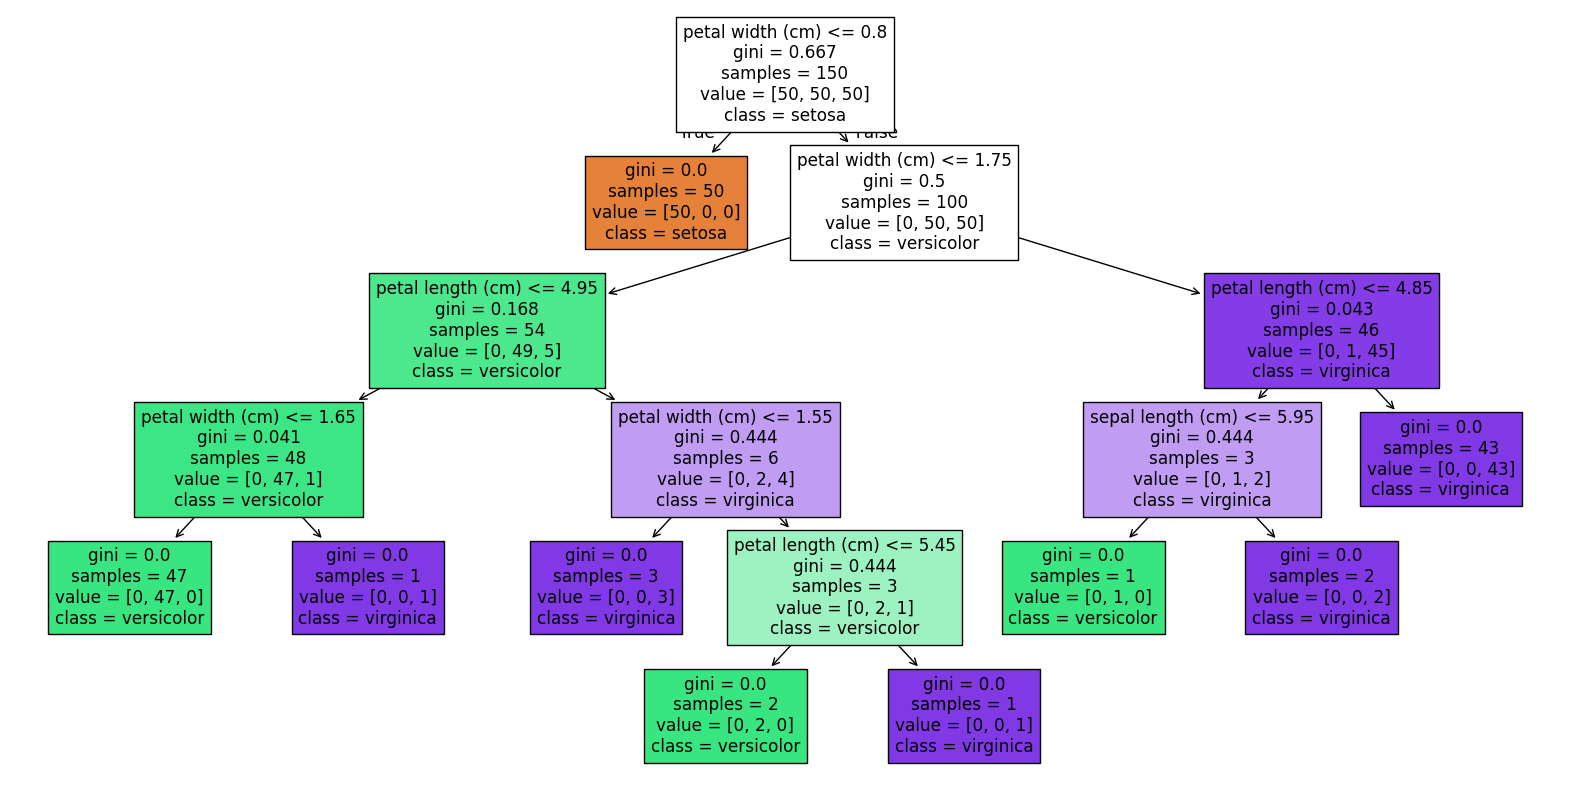

In [ ]:
import matplotlib.pyplot as plt

# Plot the decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(clf, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

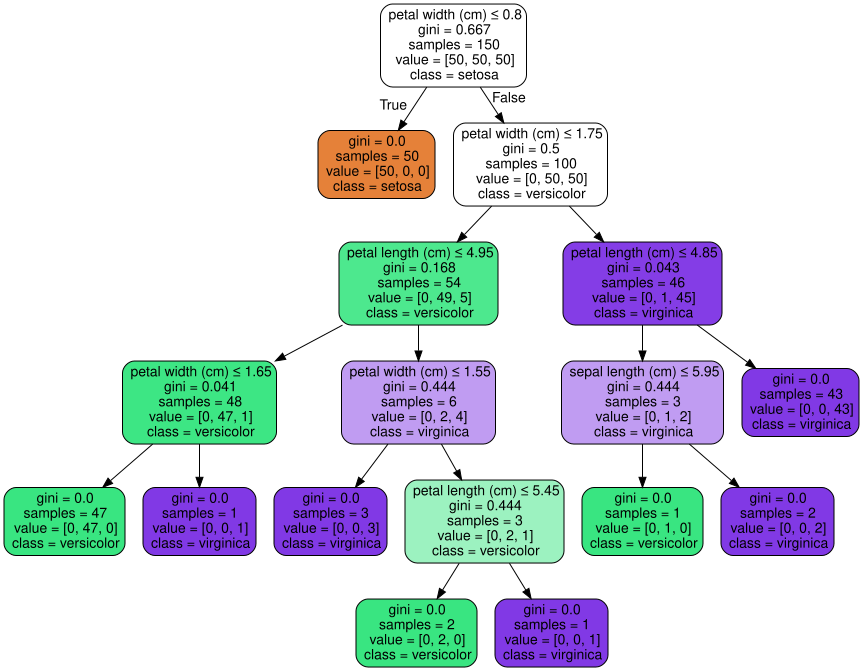

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Export decision tree to graphviz format
dot_data = export_graphviz(clf, out_file=None,
                           feature_names=iris.feature_names,
                           class_names=iris.target_names,
                           filled=True, rounded=True,
                           special_characters=True)

# Visualize decision tree using graphviz
graph = graphviz.Source(dot_data)
graph.format = 'pdf'
graph.render("iris_decision_tree")
graph # Display decision tree

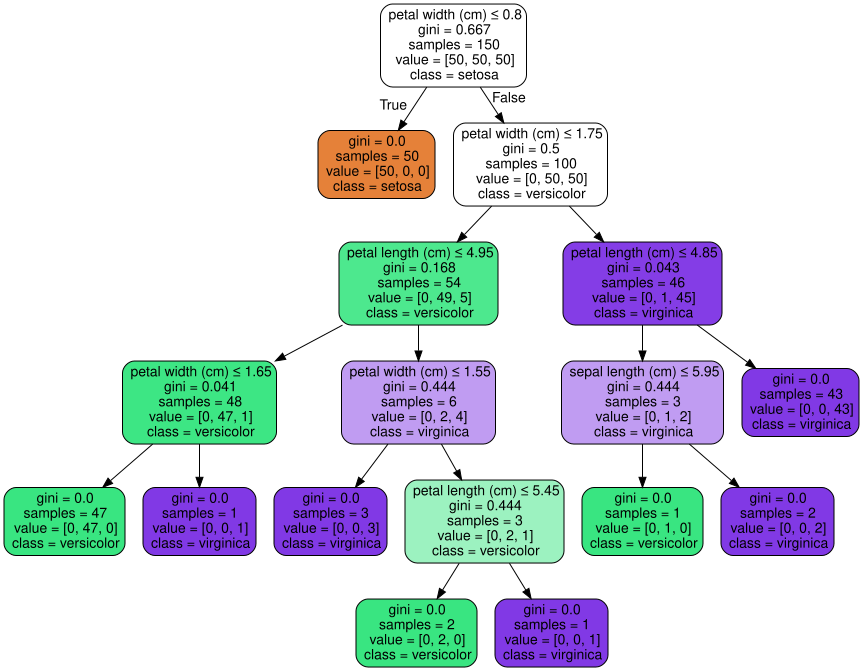

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Export decision tree to graphviz format
dot_data = export_graphviz(clf, out_file=None,
                           feature_names=iris.feature_names,
                           class_names=iris.target_names,
                           filled=True, rounded=True,
                           special_characters=True)

# Visualize decision tree using graphviz
graph = graphviz.Source(dot_data)
graph.format = 'png'
graph.render("iris_decision_tree")
graph # Display decision tree

In [ ]:
from sklearn import datasets
from sklearn import tree
from sklearn.model_selection import train_test_split

#โหลดข้อมูล iris
iris = datasets.load_iris()

#แบ่งข้อมูลเป็น 70% สำหรับ train และ 30% สำหรับ test
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, stratify=iris.target, random_state=1)

#สร้างโมเดล
clf = tree.DecisionTreeClassifier()
#train โมเดล
clf.fit(X_train, y_train)

#train  โดย map  ค่า 0,1 และ 2 กับชื่อพันธุ์กล้วยไม้
#clf.fit(X_train, iris.target_names[y_train] )

DecisionTreeClassifier()

In [ ]:
clf.predict(X_test)

array([2, 0, 0, 1, 1, 1, 2, 1, 2, 0, 0, 2, 0, 1, 0, 1, 2, 1, 1, 2, 2, 0,
       1, 2, 1, 1, 1, 2, 0, 2, 0, 0, 1, 1, 2, 2, 0, 0, 0, 1, 2, 2, 1, 0,
       0])

In [ ]:
y_test

array([2, 0, 0, 2, 1, 1, 2, 1, 2, 0, 0, 2, 0, 1, 0, 1, 2, 1, 1, 2, 2, 0,
       1, 2, 1, 1, 1, 2, 0, 2, 0, 0, 1, 1, 2, 2, 0, 0, 0, 1, 2, 2, 1, 0,
       0])

In [ ]:
import pandas as pd

# Convert iris to pandas dataframe
df = pd.DataFrame(data=X_test, columns=iris.feature_names)

# Add target column to dataframe
df['class'] = y_test
df['predited_class'] =clf.predict(X_test)

# Map target values to target names
target_names = dict(enumerate(iris.target_names))
df['class'] = df['class'].map(target_names)
df['predited_class'] = df['predited_class'].map(target_names)

# Print dataframe
df[:10]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class,predited_class
0,6.2,3.4,5.4,2.3,virginica,virginica
1,5.4,3.9,1.7,0.4,setosa,setosa
2,4.6,3.4,1.4,0.3,setosa,setosa
3,4.9,2.5,4.5,1.7,virginica,versicolor
4,6.6,3.0,4.4,1.4,versicolor,versicolor
5,6.1,2.8,4.0,1.3,versicolor,versicolor
6,6.7,2.5,5.8,1.8,virginica,virginica
7,6.2,2.2,4.5,1.5,versicolor,versicolor
8,6.4,2.7,5.3,1.9,virginica,virginica
9,5.4,3.9,1.3,0.4,setosa,setosa


In [ ]:
from sklearn import metrics
print(metrics.classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      1.00      0.97        15
           2       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
metrics.confusion_matrix(y_test, clf.predict(X_test))

array([[15,  0,  0],
       [ 0, 15,  0],
       [ 0,  1, 14]])

In [ ]:
clf.score(X_test, y_test)

0.9777777777777777

#K-Folds

In [ ]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Load the Iris dataset as an example
data = load_iris()
X = data.data
y = data.target


# Define the number of splits (k) for cross-validation
k = 4  # You can change this value to the desired number of folds

# Initialize Stratified KFold cross-validation
kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Initialize empty lists to store predictions and ground truth for all folds
all_y_true = []
all_y_pred = []
accuracy_scores=[]
confusion_matrices=[]

# Loop through each fold
for train_index, test_index in kf.split(X,y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Create a decision tree classifier
    clf = DecisionTreeClassifier(random_state=42)

    # Fit the model to the training data
    clf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = clf.predict(X_test)

    # Calculate accuracy for this fold and store it
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

    # Calculate confusion matrix and store it
    confusion = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(confusion)

    # Store ground truth and predictions for this fold
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)


# Calculate mean and standard deviation of accuracy scores
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)

# Print evaluation metrics summary
print(f"Mean Accuracy: {mean_accuracy:.2f}")
print(f"Standard Deviation of Accuracy: {std_accuracy:.2f}")

# Print average confusion matrix (you can also compute other statistics from it)
sum_confusion_matrix = np.sum(confusion_matrices, axis=0)
print("\n\nSum Confusion Matrix:")
print(sum_confusion_matrix)


# Generate a classification report for all folds and classes
report = classification_report(all_y_true, all_y_pred, target_names=data.target_names)

# Display the classification report
print("\n\nClassification Report - All Folds and Classes:")
print(report)


Mean Accuracy: 0.93
Standard Deviation of Accuracy: 0.04


Sum Confusion Matrix:
[[50  0  0]
 [ 0 45  5]
 [ 0  5 45]]


Classification Report - All Folds and Classes:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.90      0.90      0.90        50
   virginica       0.90      0.90      0.90        50

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



In [ ]:
import pandas as pd

df_cancer= pd.read_csv('/content/drive/MyDrive/DataScience/Datasets/breastCancer.csv')
df_cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df_cancer.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
df_cancer.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df_cancer.drop(["id"],axis=1,inplace=True)
df_cancer.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
y=df_cancer.diagnosis.values
x=df_cancer.drop(["diagnosis"], axis=1)

In [ ]:
from sklearn import tree
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3 ,stratify=y)
clf_cancer = tree.DecisionTreeClassifier()
clf_cancer.fit(X_train, y_train )

DecisionTreeClassifier()

In [ ]:
X_test.shape

(171, 30)

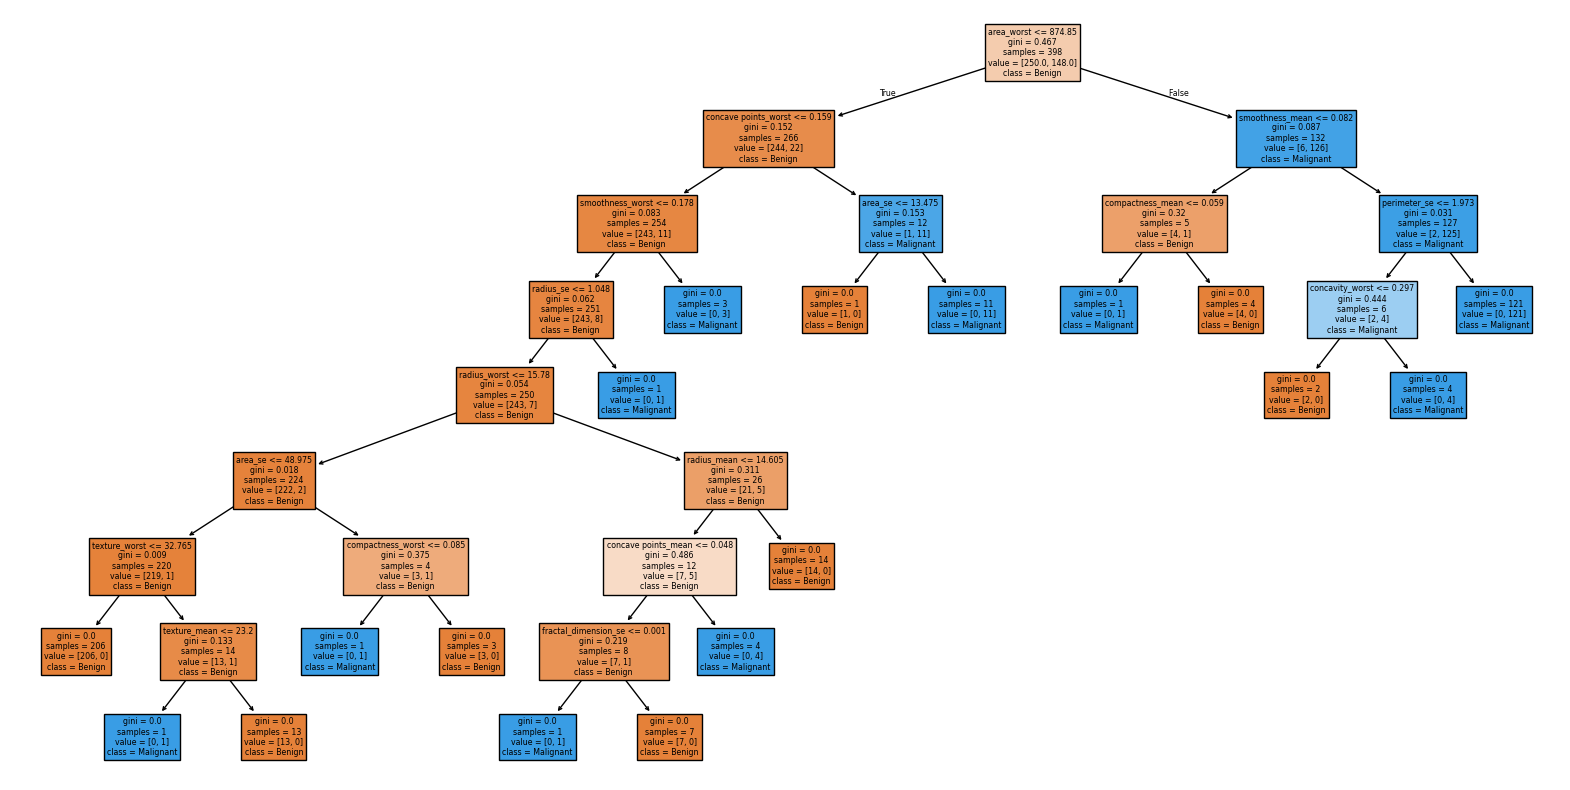

In [ ]:
import matplotlib.pyplot as plt

# Plot the decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(clf_cancer, filled=True, feature_names=x.columns, class_names=['Benign','Malignant'])
plt.show()


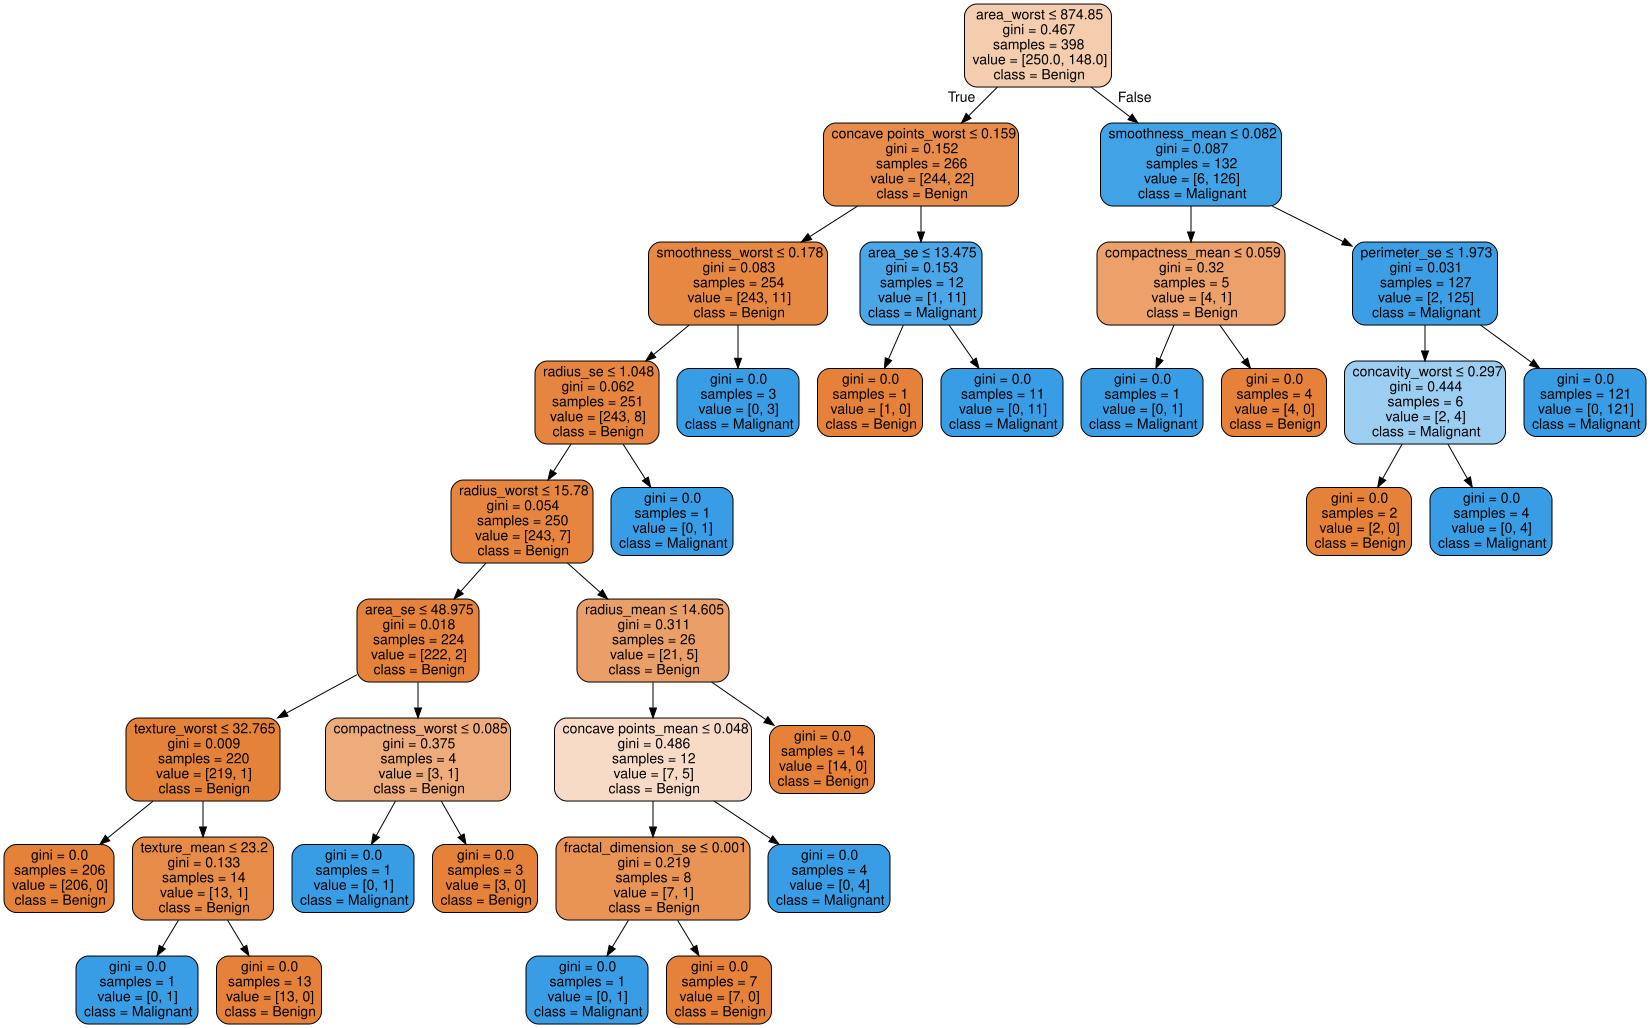

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Export decision tree to graphviz format
dot_data = export_graphviz(clf_cancer, out_file=None,
                           feature_names=x.columns,
                           class_names=['Benign','Malignant'],
                           filled=True, rounded=True,
                           special_characters=True)

# Visualize decision tree using graphviz
graph = graphviz.Source(dot_data)
graph.format = 'pdf'
graph.render("breastcancer_decision_tree")
graph # Display decision tree

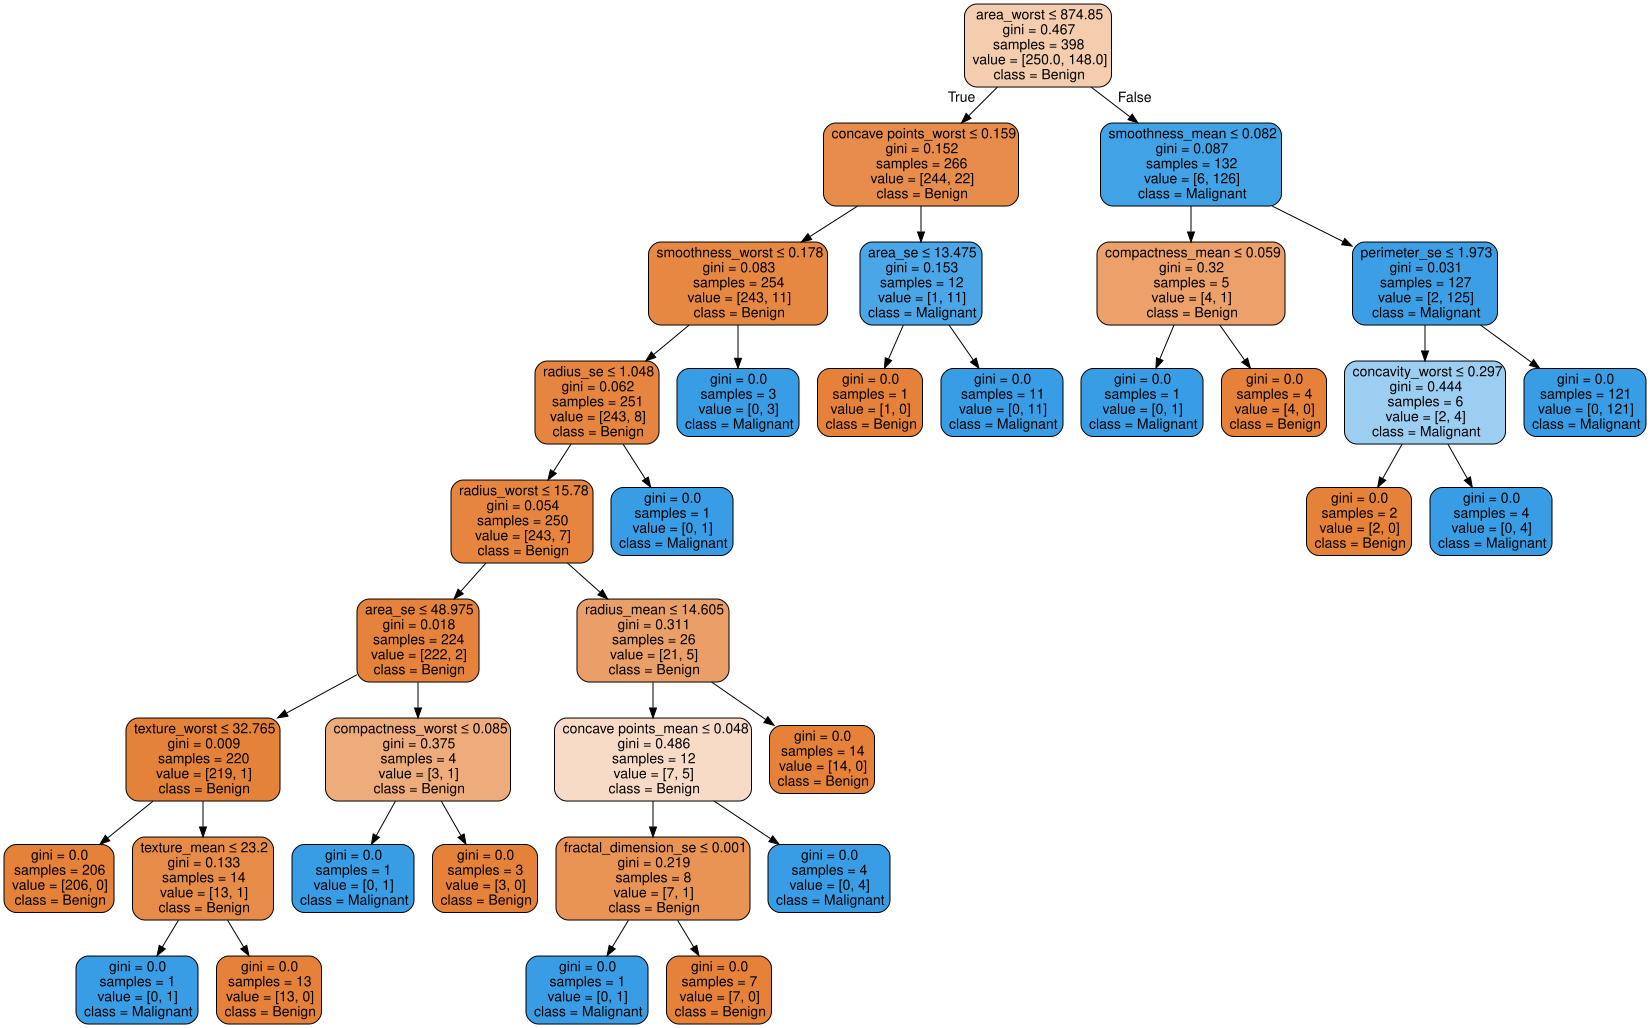

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

# Export decision tree to graphviz format
dot_data = export_graphviz(clf_cancer, out_file=None,
                           feature_names=x.columns,
                           class_names=['Benign','Malignant'],
                           filled=True, rounded=True,
                           special_characters=True)

# Visualize decision tree using graphviz
graph = graphviz.Source(dot_data)
graph.format = 'png'
graph.render("breastcancer_decision_tree")
graph # Display decision tree

In [ ]:
import pandas as pd

# Copy X_test dataframe
df_cancer_predict = X_test.copy()

# Add target column to dataframe
df_cancer_predict['predited_class'] =clf_cancer.predict(X_test)
df_cancer_predict['class'] = y_test

# Map target values to target names
target_names = {
  "M": "Malignant",
  "B": "Benign"
}
df_cancer_predict['class'] = df_cancer_predict['class'].map(target_names)
df_cancer_predict['predited_class'] = df_cancer_predict['predited_class'].map(target_names)

# Print dataframe
df_cancer_predict[:10]

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,predited_class,class
340,14.42,16.54,94.15,641.2,0.09751,0.11390,0.08007,0.04223,0.1912,0.06412,...,111.40,862.1,0.1294,0.33710,0.3755,0.14140,0.3053,0.08764,Benign,Benign
435,13.98,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,113.90,869.3,0.1613,0.35680,0.4069,0.18270,0.3179,0.10550,Malignant,Malignant
408,17.99,20.66,117.80,991.7,0.10360,0.13040,0.12010,0.08824,0.1992,0.06069,...,138.10,1349.0,0.1482,0.37350,0.3301,0.19740,0.3060,0.08503,Malignant,Malignant
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,109.50,826.4,0.1431,0.30260,0.3194,0.15650,0.2718,0.09353,Malignant,Malignant
237,20.48,21.46,132.50,1306.0,0.08355,0.08348,0.09042,0.06022,0.1467,0.05177,...,161.70,1750.0,0.1228,0.23110,0.3158,0.14450,0.2238,0.07127,Malignant,Malignant
14,13.73,22.61,93.60,578.3,0.11310,0.22930,0.21280,0.08025,0.2069,0.07682,...,108.80,697.7,0.1651,0.77250,0.6943,0.22080,0.3596,0.14310,Malignant,Malignant
448,14.53,19.34,94.25,659.7,0.08388,0.07800,0.08817,0.02925,0.1473,0.05746,...,108.10,830.5,0.1089,0.26490,0.3779,0.09594,0.2471,0.07463,Benign,Benign
102,12.18,20.52,77.22,458.7,0.08013,0.04038,0.02383,0.01770,0.1739,0.05677,...,84.58,547.8,0.1123,0.08862,0.1145,0.07431,0.2694,0.06878,Malignant,Benign
353,15.08,25.74,98.00,716.6,0.10240,0.09769,0.12350,0.06553,0.1647,0.06464,...,121.20,1050.0,0.1660,0.23560,0.4029,0.15260,0.2654,0.09438,Malignant,Malignant
465,13.24,20.13,86.87,542.9,0.08284,0.12230,0.10100,0.02833,0.1601,0.06432,...,115.00,733.5,0.1201,0.56460,0.6556,0.13570,0.2845,0.12490,Benign,Benign


In [ ]:
from sklearn import metrics
print(metrics.classification_report(y_test, clf_cancer.predict(X_test)))

              precision    recall  f1-score   support

           B       0.95      0.91      0.93       107
           M       0.86      0.92      0.89        64

    accuracy                           0.91       171
   macro avg       0.90      0.91      0.91       171
weighted avg       0.92      0.91      0.91       171



In [ ]:
metrics.confusion_matrix(y_test, clf_cancer.predict(X_test))

array([[97, 10],
       [ 5, 59]])

In [ ]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

X=x

# Define the number of splits (k) for cross-validation
k = 4  # You can change this value to the desired number of folds

# Initialize Stratified KFold cross-validation
kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Initialize empty lists to store predictions and ground truth for all folds
all_y_true = []
all_y_pred = []
accuracy_scores=[]
confusion_matrices=[]

# Loop through each fold
for train_index, test_index in kf.split(X,y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Create a decision tree classifier
    clf = DecisionTreeClassifier(random_state=42)

    # Fit the model to the training data
    clf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = clf.predict(X_test)

    # Calculate accuracy for this fold and store it
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

    # Calculate confusion matrix and store it
    confusion = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(confusion)

    # Store ground truth and predictions for this fold
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)


# Calculate mean and standard deviation of accuracy scores
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)

# Print evaluation metrics summary
print(f"Mean Accuracy: {mean_accuracy:.2f}")
print(f"Standard Deviation of Accuracy: {std_accuracy:.2f}")

# Print average confusion matrix (you can also compute other statistics from it)
sum_confusion_matrix = np.sum(confusion_matrices, axis=0)
print("\n\nSum Confusion Matrix:")
print(sum_confusion_matrix)


# Generate a classification report for all folds and classes
report = classification_report(all_y_true, all_y_pred, target_names=['Benign','Malignant'])

# Display the classification report
print("\n\nClassification Report - All Folds and Classes:")
print(report)

Mean Accuracy: 0.91
Standard Deviation of Accuracy: 0.03


Sum Confusion Matrix:
[[334  23]
 [ 28 184]]


Classification Report - All Folds and Classes:
              precision    recall  f1-score   support

      Benign       0.92      0.94      0.93       357
   Malignant       0.89      0.87      0.88       212

    accuracy                           0.91       569
   macro avg       0.91      0.90      0.90       569
weighted avg       0.91      0.91      0.91       569

